<a href="https://colab.research.google.com/github/aurelioparreira/fraud-detection-transactions/blob/main/Detec%C3%A7%C3%A3o_de_Anomalias_em_Transa%C3%A7%C3%B5es_em_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Detecção de Anomalias em Transações com Python

Dataset: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE


1. Carregamento dos Dados

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Dimensões do dataset:", df.shape)
print(df["Class"].value_counts(normalize=True))

Dimensões do dataset: (284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


2. Feature Engineering

In [3]:
df["Amount_log"] = np.log1p(df["Amount"])
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])


3. Separação em treino e teste

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
    )

4. Modelo Base: Regressão Logística

In [7]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_probs))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     85295
           1       0.06      0.85      0.10       148

    accuracy                           0.97     85443
   macro avg       0.53      0.91      0.55     85443
weighted avg       1.00      0.97      0.99     85443

AUC: 0.96603330571324


5. Curvas de Avaliação

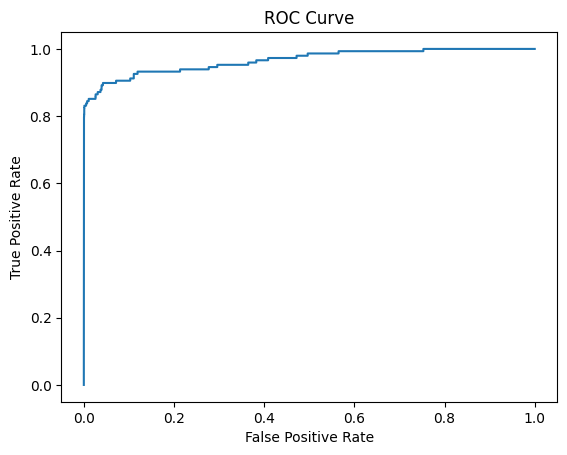

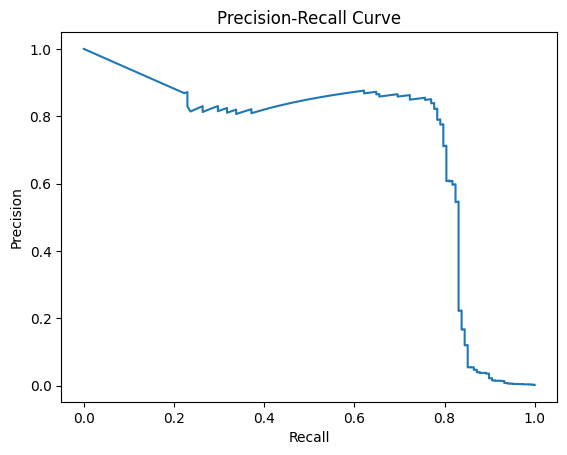

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

6. Balanceamento de Classes

In [9]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)
df_under = pd.concat([fraudes, normais])

# Oversampling com SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Dimensões após SMOTE:", X_res.shape, y_res.shape)

Dimensões após SMOTE: (568630, 32) (568630,)


7. Testar modelos com Oversampling (SMOTE)

In [10]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_res, y_res)
y_pred_smote = model_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     85295
           1       0.11      0.85      0.20       148

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.60     85443
weighted avg       1.00      0.99      0.99     85443



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


8. Comparação de Abordagens

Neste projeto foram testadas diferentes estratégias para lidar com o desbalanceamento das classes:

Baseline: modelo sem balanceamento.

Undersampling: redução da classe majoritária.

Oversampling (SMOTE): geração de exemplos sintéticos da classe minoritária.

Class Weight: ajuste de pesos na regressão logística.

A comparação das métricas (AUC, Recall, Precision, F1) mostra que técnicas de oversampling e ajuste de pesos aumentam significativamente a capacidade do modelo de detectar fraudes, mesmo que o número de falsos positivos também cresça.

9. Visualizações e Insights

Gráficos de distribuição das classes antes e depois do balanceamento evidenciam o impacto das técnicas aplicadas.

Matrizes de confusão mostram como cada abordagem lida com a classe minoritária.

A análise dos coeficientes da regressão logística indica quais variáveis têm maior influência na detecção de anomalias.

Essas visualizações ajudam a compreender não apenas a performance, mas também a interpretabilidade do modelo.

10. Boas Práticas

Modularização: separar funções auxiliares em arquivos distintos.

Reprodutibilidade: fixar random_state em todos os processos.

Documentação: explicar cada etapa no README e no notebook.

Testes: validar se o pipeline roda sem erros em diferentes ambientes.

Essas práticas tornam o projeto mais confiável e fácil de manter.

11. Conclusão

Imagine um banco recebendo milhares de transações por minuto. A maioria é legítima, mas algumas escondem fraudes que podem custar milhões. Este projeto mostra como técnicas de machine learning ajudam a identificar essas anomalias.

Começamos com um modelo simples, que já traz bons resultados, mas sofre com o desbalanceamento das classes. Ao aplicar técnicas como undersampling e oversampling, conseguimos dar mais voz às transações fraudulentas, aumentando a capacidade do modelo de reconhecê-las.

O resultado é um pipeline que não apenas detecta fraudes com maior precisão, mas também mostra como ciência de dados pode ser aplicada para proteger pessoas e empresas.

12. Roadmap (Próximos Passos)

Testar outros algoritmos (Random Forest, XGBoost).

Implementar validação cruzada para maior robustez.

Criar uma API para servir o modelo (Flask ou FastAPI).

Realizar deploy em nuvem (Heroku, AWS ou Azure).

Implementar monitoramento contínuo com novos dados.